# Installation

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import logomaker
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, roc_curve, average_precision_score, auc
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

In [23]:
def show_important_bases(idx, context_size, is_mutated, nucl, weights):

  if is_mutated:
    motif = ['T', 'T']
    title = 'Top 10 Most Significant Context Position \n Weights for Class 1'
  else:
    motif = ['T', 'C']
    title = 'Top 10 Most Significant Context Position \n Weights for Class 0'

  positions = np.concatenate([idx, [context_size, context_size+1]])
  nucleotides = np.concatenate([nucl, motif])[np.argsort(positions)]

  if is_mutated:
    weights_ = np.concatenate([weights, [0, 0]])[np.argsort(positions)]
  else:
    weights_ = np.abs(np.concatenate([weights, [0, 0]])[np.argsort(positions)])

  positions = np.sort(positions) - context_size
  fig, ax = plt.subplots(figsize=(8, 5))
  x_indices = range(len(positions))
  bars = ax.bar(x_indices, weights_, edgecolor='black', alpha=0.8)

  ax.set_title(title, fontsize=16)
  ax.set_ylim(0, 1.4)
  ax.set_xticks(x_indices)
  ax.set_xticklabels(positions)
  ax.set_xlabel('Nucleotide Context Position', fontsize=12)
  ax.set_ylabel('Weight Coefficient', fontsize=12)
  ax.axhline(0, color='black', linewidth=1)
  plt.xticks(fontsize=12)
  plt.yticks(fontsize=12)

  for i, bar in enumerate(bars):
      yval = bar.get_height()
      va = 'top' if yval < 0 else 'bottom'

      offset = -0.04 if yval < 0 else 0.04
      text_color = 'red' if positions[i] in [0, 1] else 'black'
      ax.text(bar.get_x() + bar.get_width()/2, yval + offset, nucleotides[i],
              ha='center', va=va, fontsize=20, color=text_color)

  plt.tight_layout()
  plt.show()

In [24]:
def model_interpretation(model, context_size):

  weights = model.coef_[0]
  weights_reshaped = weights.reshape(context_size*2+2, 4)

  bases = np.array(['A', 'C', 'G', 'T'])

  biggest_idx = np.sort(np.argsort(np.max(weights_reshaped, axis=1))[-10:])
  nucl_mutated = bases[np.argmax(weights_reshaped[biggest_idx],axis=1)]
  weights_mutated = np.max(weights_reshaped[biggest_idx],axis=1)

  show_important_bases(biggest_idx, context_size, True, nucl_mutated, weights_mutated)

  smallest_idx = np.sort(np.argsort(np.min(weights_reshaped, axis=1))[:10])
  nucl_not_mutated = bases[np.argmin(weights_reshaped[smallest_idx],axis=1)]
  weights_not_mutated = np.min(weights_reshaped[smallest_idx],axis=1)

  show_important_bases(smallest_idx, context_size, False, nucl_not_mutated, weights_not_mutated)

In [25]:
def show_logo(model, context_size):
  alphabet = ['A', 'C', 'G', 'T']
  weights_ = model.coef_[0]
  weights = weights_.reshape(context_size*2+2, 4)
  df_weights_full = pd.DataFrame(weights, columns=alphabet)
  df_weights = df_weights_full.iloc[context_size-4:context_size+6].reset_index(drop=True)


  df_class_1 = df_weights.clip(lower=0)
  df_class_0 = df_weights.clip(upper=0).abs()
  max_1 = df_class_1.max().max() if df_class_1.max().max() > 0 else 2.0
  max_0 = df_class_0.max().max() if df_class_0.max().max() > 0 else 2.0
  df_class_1.iloc[4] = 0.0
  df_class_1.at[4, 'T'] = max_1
  df_class_1.iloc[5] = 0.0
  df_class_1.at[5, 'C'] = max_1
  df_class_0.iloc[4] = 0.0
  df_class_0.at[4, 'T'] = max_0
  df_class_0.iloc[5] = 0.0
  df_class_0.at[5, 'C'] = max_0
  custom_ticks = ['-4', '-3', '-2', '-1', '0', '1', '2', '3', '4', '5']
  fig1, ax1 = plt.subplots(figsize=(6, 3.5))
  logo_1 = logomaker.Logo(df_class_1, ax=ax1, color_scheme='classic')

  ax1.set_title('Nucleotide Context for Class 1')
  ax1.set_ylabel('Weight')
  ax1.set_xlabel('Position relative to center')
  ax1.set_xticks(range(len(df_weights)))
  ax1.set_xticklabels(custom_ticks)
  ax1.spines['right'].set_visible(False)
  ax1.spines['top'].set_visible(False)
  fig1.tight_layout()


  fig2, ax2 = plt.subplots(figsize=(6, 3.5))
  logo_0 = logomaker.Logo(df_class_0, ax=ax2, color_scheme='classic')
  ax2.set_title('Nucleotide Context for Class 0')
  ax2.set_ylabel('Weight (absolute value)')
  ax2.set_xlabel('Position relative to center')
  ax2.set_xticks(range(len(df_weights)))
  ax2.set_xticklabels(custom_ticks)
  ax2.spines['right'].set_visible(False)
  ax2.spines['top'].set_visible(False)
  fig2.tight_layout()

  plt.show()

In [26]:
data = np.load('data/processed/models_input.npz')

X_50 = data['X_50']
X_30 = data['X_30']
y = data['y']
Z = data['Z']
pos = data['pos']

weights = 1 + np.log1p(Z)

# Classification of 50-bp Nucleotide Context

## Model Initialization and Training

In [27]:
X_train_50, X_test_50, y_train_50, y_test_50 = train_test_split(
    X_50, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000]}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_50 = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, penalty='l2', class_weight='balanced'),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)

grid_search_50.fit(X_train_50, y_train_50)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000]},
             scoring='f1')

In [29]:
print(f'Best parameters from Grid Search: {grid_search_50.best_params_}')
print(f'Best F1-score (Validation): {grid_search_50.best_score_:.4f}')

Best parameters from Grid Search: {'C': 10}
Best F1-score (Validation): 0.2371


In [30]:
log_reg_50 = LogisticRegression(max_iter=1000, penalty='l2', C=grid_search_50.best_params_['C'], class_weight='balanced')
log_reg_50.fit(X_train_50, y_train_50)

LogisticRegression(C=10, class_weight='balanced', max_iter=1000)

## Evaluation Metrics

In [31]:
y_pred_50 = log_reg_50.predict(X_test_50)
y_prob_50 = log_reg_50.predict_proba(X_test_50)[:, 1]

In [32]:
print(classification_report(y_test_50, y_pred_50))
print(f"ROC-AUC: {roc_auc_score(y_test_50, y_prob_50):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.66      0.78      4230
           1       0.16      0.61      0.25       433

    accuracy                           0.66      4663
   macro avg       0.55      0.64      0.51      4663
weighted avg       0.87      0.66      0.73      4663

ROC-AUC: 0.6881


In [33]:
fpr_50, tpr_50, _ = roc_curve(y_test_50,  y_prob_50)

In [34]:
precision_50, recall_50, thresholds_50 = precision_recall_curve(y_test_50, y_prob_50)

## Model Interpretation

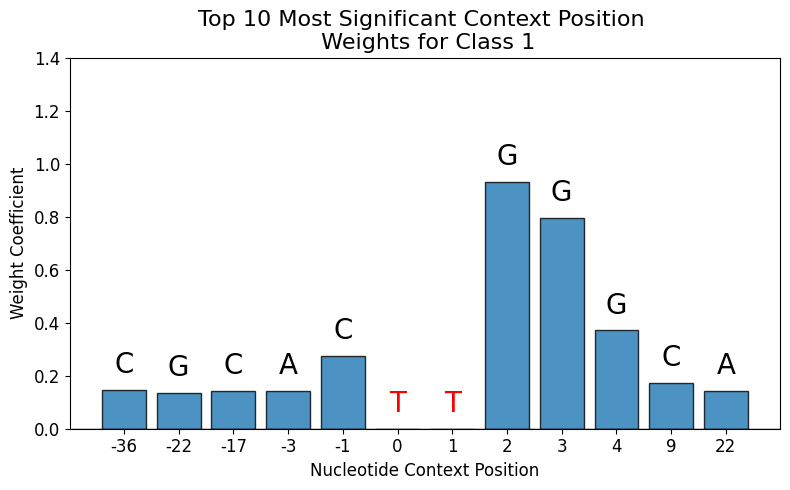

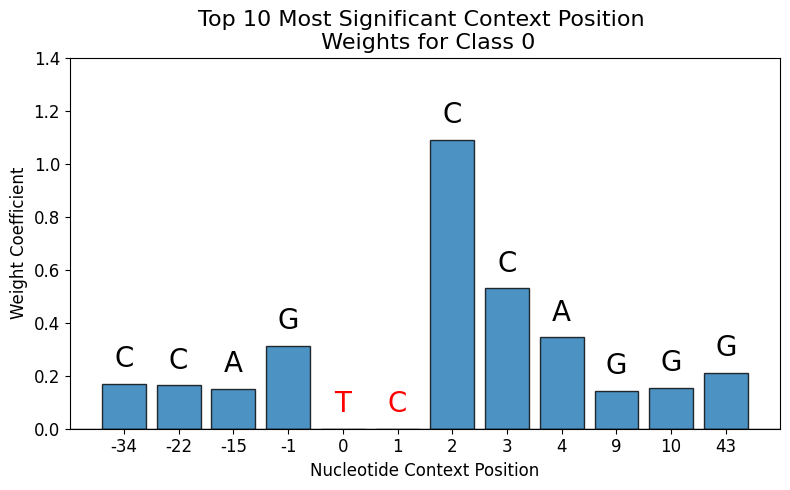

In [35]:
model_interpretation(log_reg_50, 50)

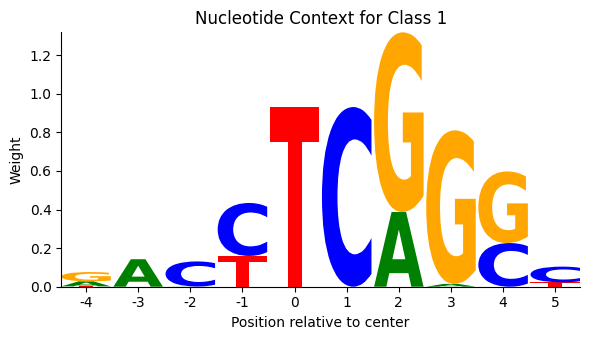

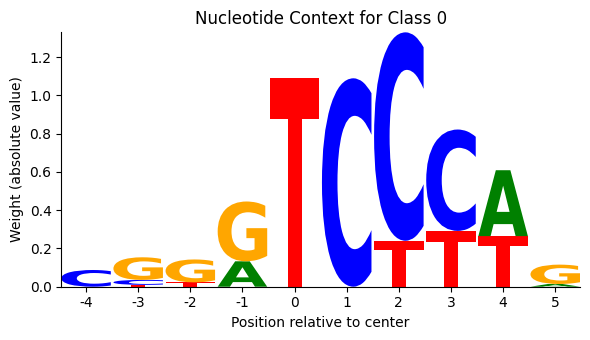

In [36]:
show_logo(log_reg_50, 50)

# Classification of 30-bp Nucleotide Context

## Model Initialization and Training

In [37]:
X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
    X_30, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000]}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_30 = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, penalty='l2', class_weight='balanced'),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)

grid_search_30.fit(X_train_30, y_train_30)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000]},
             scoring='f1')

In [39]:
print(f'Best parameters from Grid Search: {grid_search_30.best_params_}')
print(f'Best F1-score (Validation): {grid_search_30.best_score_:.4f}')

Best parameters from Grid Search: {'C': 0.1}
Best F1-score (Validation): 0.2431


In [40]:
log_reg_30 = LogisticRegression(max_iter=1000, penalty='l2', C=grid_search_30.best_params_['C'], class_weight='balanced')
log_reg_30.fit(X_train_30, y_train_30)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000)

## Evaluation Metrics

In [41]:
y_pred_30 = log_reg_30.predict(X_test_30)
y_prob_30 = log_reg_30.predict_proba(X_test_30)[:, 1]

In [42]:
print(classification_report(y_test_30, y_pred_30))
print(f"ROC-AUC: {roc_auc_score(y_test_30, y_prob_30):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.66      0.77      4230
           1       0.16      0.63      0.25       433

    accuracy                           0.65      4663
   macro avg       0.55      0.64      0.51      4663
weighted avg       0.87      0.65      0.73      4663

ROC-AUC: 0.7010


In [43]:
fpr_30, tpr_30, _ = roc_curve(y_test_30,  y_prob_30)

In [44]:
precision_30, recall_30, thresholds_30 = precision_recall_curve(y_test_30, y_prob_30)

## Model Interpretation

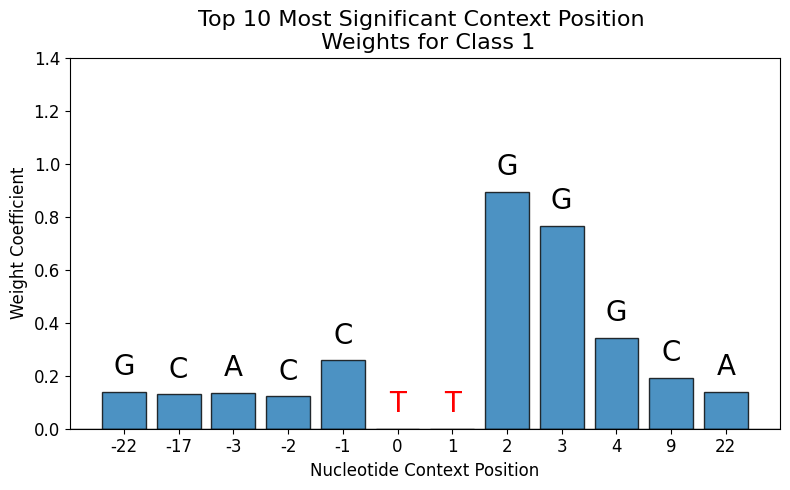

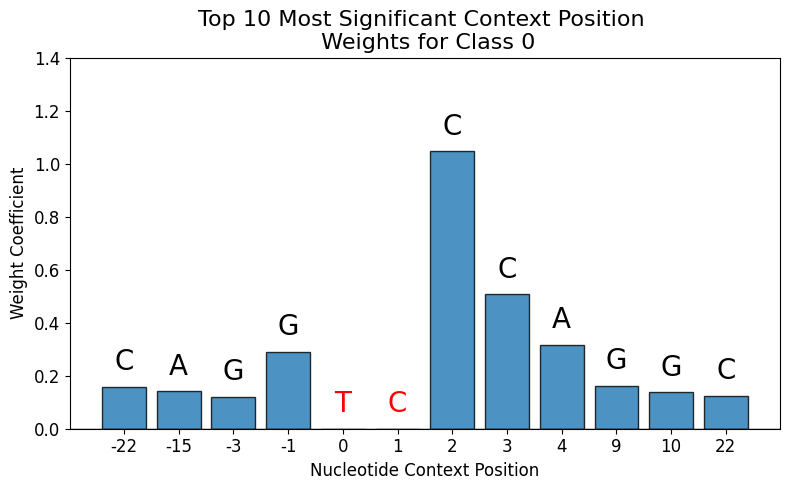

In [45]:
model_interpretation(log_reg_30, 30)

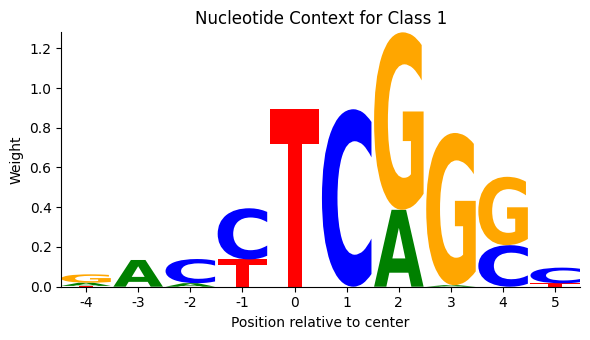

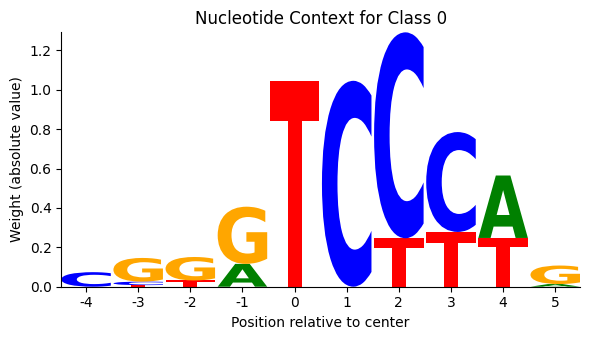

In [46]:
show_logo(log_reg_30, 30)

# Weighted Classification of 50-bp Nucleotide Context

## Model Initialization and Training

In [47]:
X_train_w_50, X_test_w_50, y_train_w_50, y_test_w_50, w_train_50, w_test_50 = train_test_split(
    X_50, y, weights, test_size=0.2, random_state=42, stratify=y)

In [48]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000]}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_w_50 = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, penalty='l2', class_weight='balanced'),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)

grid_search_w_50.fit(X_train_w_50, y_train_w_50, sample_weight=w_train_50)


print(f'Best parameters from Grid Search: {grid_search_w_50.best_params_}')
print(f'Best F1-score (Validation): {grid_search_w_50.best_score_:.4f}')

Best parameters from Grid Search: {'C': 10}
Best F1-score (Validation): 0.2190


In [49]:
log_reg_w_50 = LogisticRegression(max_iter=1000, penalty='l2', C=grid_search_w_50.best_params_['C'], class_weight='balanced')
log_reg_w_50.fit(X_train_w_50, y_train_w_50, sample_weight=w_train_50)

LogisticRegression(C=10, class_weight='balanced', max_iter=1000)

## Evaluation Metrics

In [50]:
y_pred_w_50 = log_reg_w_50.predict(X_test_w_50)
y_prob_w_50 = log_reg_w_50.predict_proba(X_test_w_50)[:, 1]

In [51]:
print(classification_report(y_test_w_50, y_pred_w_50))
print(f"ROC-AUC: {roc_auc_score(y_test_w_50, y_prob_w_50):.4f}")

              precision    recall  f1-score   support

           0       0.95      0.43      0.59      4230
           1       0.12      0.79      0.22       433

    accuracy                           0.47      4663
   macro avg       0.54      0.61      0.40      4663
weighted avg       0.88      0.47      0.56      4663

ROC-AUC: 0.6864


In [52]:
fpr_50_w, tpr_50_w, _ = roc_curve(y_test_w_50,  y_prob_w_50)

In [53]:
precision_50_w, recall_50_w, thresholds_50_w = precision_recall_curve(y_test_w_50, y_prob_w_50)

## Model Interpretation

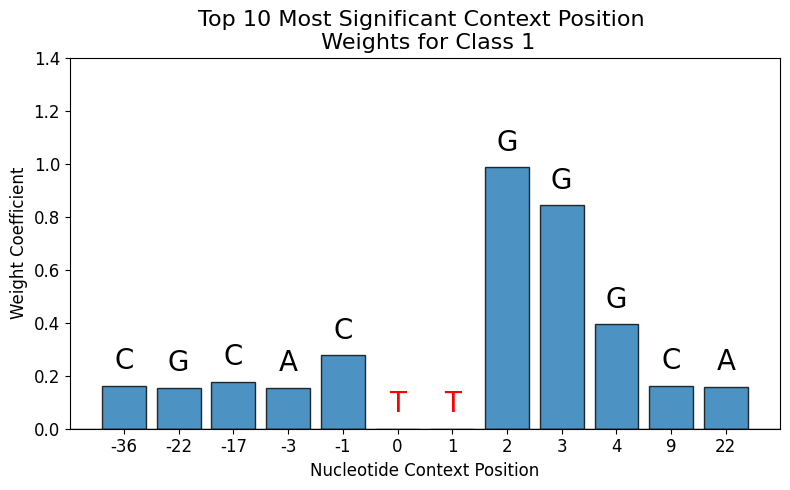

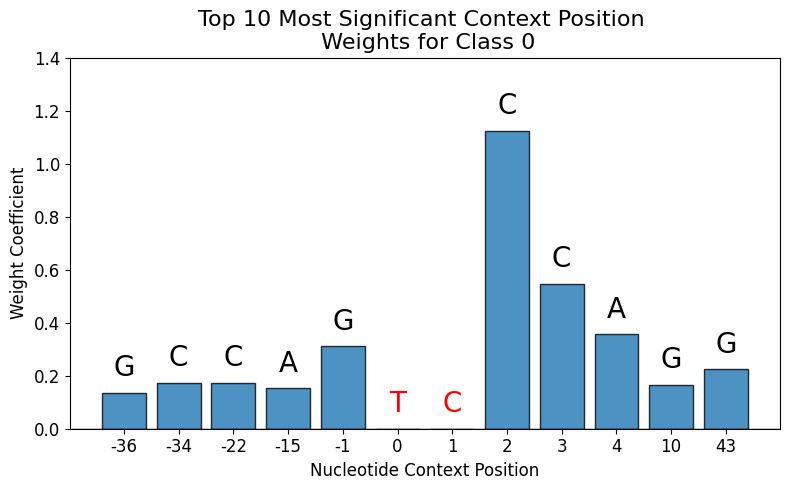

In [54]:
model_interpretation(log_reg_w_50, 50)

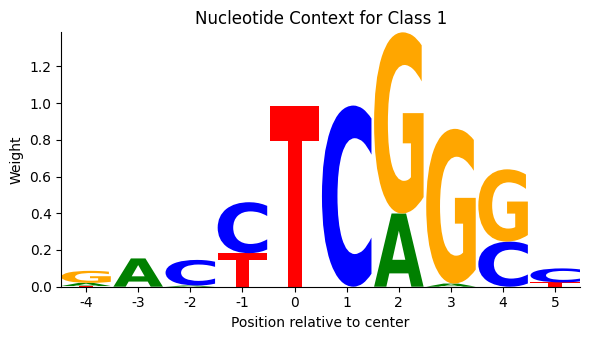

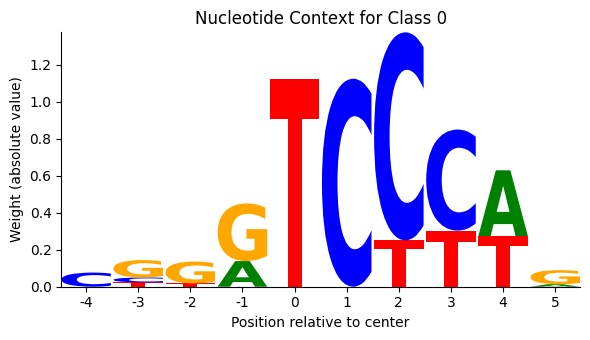

In [55]:
show_logo(log_reg_w_50, 50)

# Weighted Classification of 30-bp Nucleotide Context

## Model Initialization and Training

In [56]:
X_train_w_30, X_test_w_30, y_train_w_30, y_test_w_30, w_train_30, w_test_30 = train_test_split(
    X_30, y, weights, test_size=0.2, random_state=42, stratify=y)

In [57]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000]}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_w_30 = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, penalty='l2', class_weight='balanced'),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)

grid_search_w_30.fit(X_train_w_30, y_train_w_30, sample_weight=w_train_30)


print(f'Best parameters from Grid Search: {grid_search_w_30.best_params_}')
print(f'Best F1-score (Validation): {grid_search_w_30.best_score_:.4f}')

Best parameters from Grid Search: {'C': 10}
Best F1-score (Validation): 0.2168


In [58]:
log_reg_w_30 = LogisticRegression(max_iter=1000, penalty='l2', C=0.1, class_weight='balanced')
log_reg_w_30.fit(X_train_w_30, y_train_w_30, sample_weight=w_train_30)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000)

## Evaluation Metrics

In [59]:
y_pred_w_30 = log_reg_w_30.predict(X_test_w_30)
y_prob_w_30 = log_reg_w_30.predict_proba(X_test_w_30)[:, 1]

In [60]:
print(classification_report(y_test_w_30, y_pred_w_30))
print(f"ROC-AUC: {roc_auc_score(y_test_w_30, y_prob_w_30):.4f}")

              precision    recall  f1-score   support

           0       0.96      0.41      0.57      4230
           1       0.12      0.82      0.22       433

    accuracy                           0.45      4663
   macro avg       0.54      0.61      0.40      4663
weighted avg       0.88      0.45      0.54      4663

ROC-AUC: 0.6990


In [61]:
fpr_30_w, tpr_30_w, _ = roc_curve(y_test_w_30,  y_prob_w_30)

In [62]:
precision_30_w, recall_30_w, thresholds_30_w = precision_recall_curve(y_test_w_30, y_prob_w_30)

## Model Interpretation

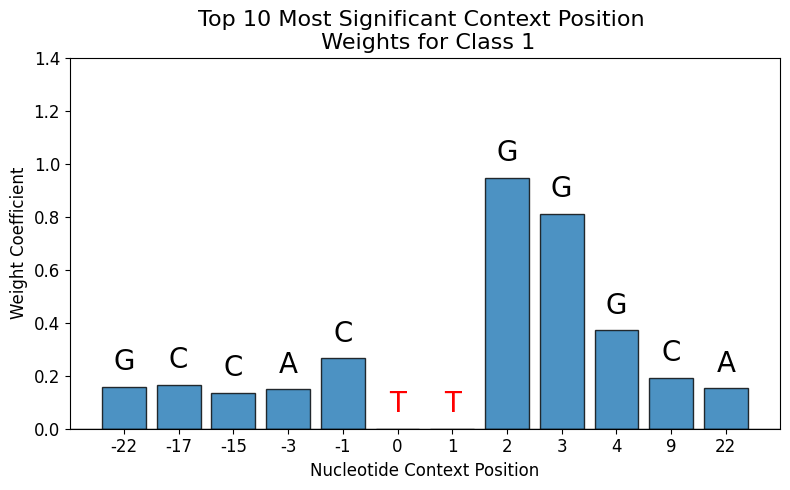

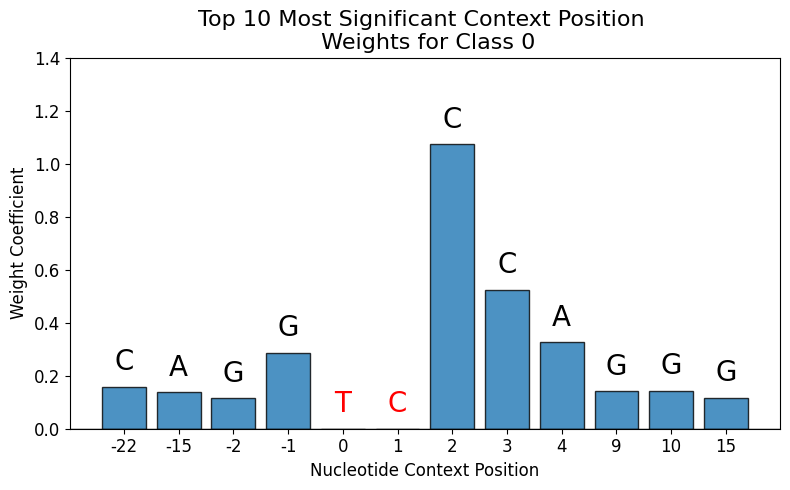

In [63]:
model_interpretation(log_reg_w_30, 30)

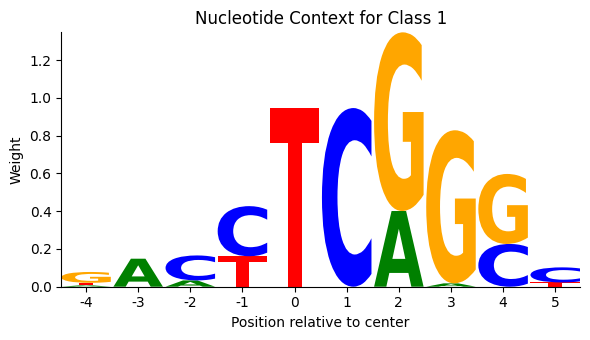

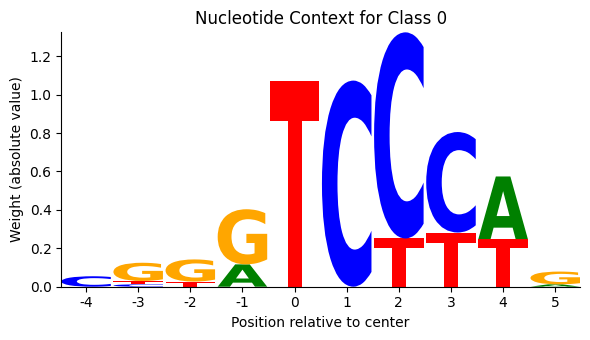

In [64]:
show_logo(log_reg_w_30, 30)

# Adding Features

In [71]:
df = pd.DataFrame({'pos': pos, 'seq_50':list(X_50), 'seq_30':list(X_30), 'label': y})
score_df = pd.read_pickle('data/processed/grantham_score.pkl.gz')
score_df.score = score_df.score.fillna(215)

df = df.merge(score_df[['pos', 'score']], on='pos', how='left')
df.score = df.score.fillna(0)

In [72]:
add_features = pd.read_pickle('data/processed/dataframe_features.pkl.gz')

In [73]:
df_featured = df[df.pos.isin(add_features.pos_in_align)]
df_featured = df_featured.merge(
    add_features[['pos_in_align', 'Free_Energy_kcal_mol', 'Stem_Length', 'Loop_Length', 'energy_isna', 'stem_isna', 'loop_isna']],
    left_on='pos',
    right_on='pos_in_align',
    how='left'
)

df_featured = df_featured.drop(columns=['pos_in_align'])

In [74]:
features = df_featured[['score', 'Free_Energy_kcal_mol', 'Stem_Length', 'Loop_Length', 'energy_isna', 'stem_isna', 'loop_isna']].values

X_50_featured = np.hstack((np.vstack(df_featured.seq_50), features))
X_30_featured = np.hstack((np.vstack(df_featured.seq_30), features))

y_featured = df_featured.label.to_numpy()

# Classification of 50-bp Nucleotide Context with Additional Features

## Model Initialization and Training

In [119]:
X_train_50_featured, X_test_50_featured, y_train_50_featured, y_test_50_featured = train_test_split(
    X_50_featured, y_featured, test_size=0.2, random_state=42, stratify=y_featured)

In [120]:
scaler = StandardScaler()

X_train_50_scaled = scaler.fit_transform(X_train_50_featured)
X_test_50_scaled = scaler.transform(X_test_50_featured)

In [121]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000]}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_50_featured = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, penalty='l2', class_weight='balanced'),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)

grid_search_50_featured.fit(X_train_50_scaled, y_train_50_featured)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000]},
             scoring='f1')

In [122]:
print(f'Best parameters from Grid Search: {grid_search_50_featured.best_params_}')
print(f'Best F1-score (Validation): {grid_search_50_featured.best_score_:.4f}')

Best parameters from Grid Search: {'C': 0.01}
Best F1-score (Validation): 0.2371


In [123]:
log_reg_50_featured = LogisticRegression(max_iter=1000, penalty='l2', C=grid_search_50_featured.best_params_['C'], class_weight='balanced')
log_reg_50_featured.fit(X_train_50_scaled, y_train_50_featured)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000)

## Evaluation Metrics

In [124]:
y_pred_50_featured = log_reg_50_featured.predict(X_test_50_scaled)
y_prob_50_featured = log_reg_50_featured.predict_proba(X_test_50_scaled)[:, 1]

In [125]:
print(classification_report(y_test_50_featured, y_pred_50_featured))
print(f"ROC-AUC: {roc_auc_score(y_test_50_featured, y_prob_50_featured):.4f}")

              precision    recall  f1-score   support

           0       0.95      0.66      0.78      4229
           1       0.16      0.63      0.26       432

    accuracy                           0.66      4661
   macro avg       0.55      0.65      0.52      4661
weighted avg       0.87      0.66      0.73      4661

ROC-AUC: 0.7019


In [126]:
fpr_50_featured, tpr_50_featured, _ = roc_curve(y_test_50_featured,  y_prob_50_featured)

In [127]:
precision_50_featured, recall_50_featured, thresholds_50_featured = precision_recall_curve(y_test_50_featured, y_prob_50_featured)

## Features Interpretation

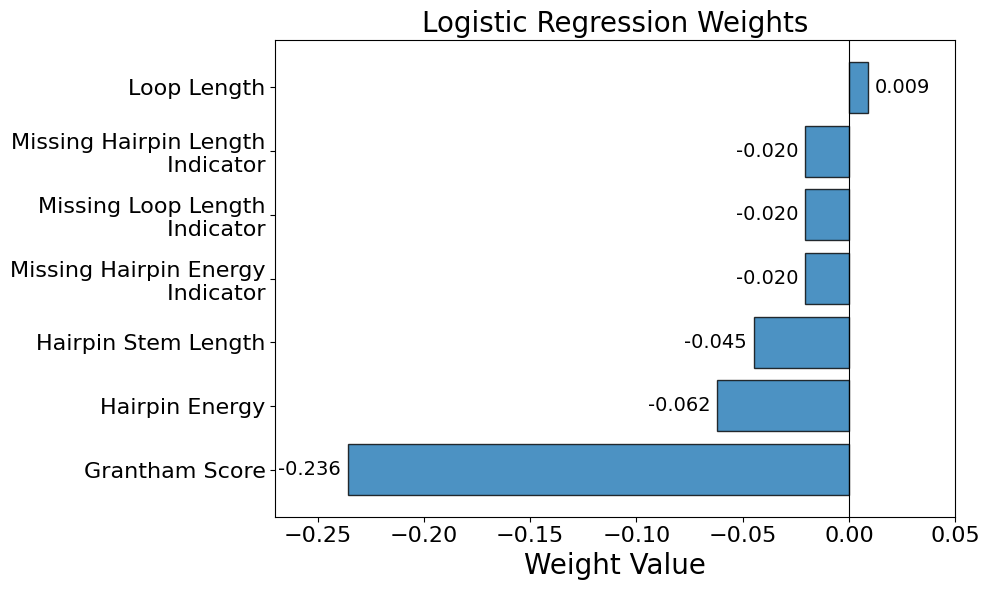

In [128]:
weight_features = log_reg_50_featured.coef_[0][-7:]
features_name = [
    'Grantham Score',
    'Hairpin Energy',
    'Hairpin Stem Length',
    'Loop Length',
    'Missing Hairpin Energy\n Indicator',
    'Missing Hairpin Length\n Indicator',
    'Missing Loop Length\n Indicator'
]

df_weights = pd.DataFrame({'feature': features_name, 'weight': weight_features})
df_weights = df_weights.sort_values(by='weight')


fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_weights['feature'], df_weights['weight'], edgecolor='black', alpha=0.8)
ax.bar_label(bars, fmt='%.3f', padding=5, fontsize=14)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlim(-0.27, 0.05)
ax.set_title('Logistic Regression Weights', fontsize=20)
ax.set_xlabel('Weight Value', fontsize=20)
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# Classification of 30-bp Nucleotide Context with Additional Features

## Model Initialization and Training

In [129]:
X_train_30_featured, X_test_30_featured, y_train_30_featured, y_test_30_featured = train_test_split(
    X_30_featured, y_featured, test_size=0.2, random_state=42, stratify=y_featured)

In [130]:
scaler = StandardScaler()

X_train_30_scaled = scaler.fit_transform(X_train_30_featured)
X_test_30_scaled = scaler.transform(X_test_30_featured)

In [131]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000]}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_30_featured = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, penalty='l2', class_weight='balanced'),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)

grid_search_30_featured.fit(X_train_30_scaled, y_train_30_featured)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000]},
             scoring='f1')

In [132]:
print(f'Best parameters from Grid Search: {grid_search_30_featured.best_params_}')
print(f'Best F1-score (Validation): {grid_search_30_featured.best_score_:.4f}')

Best parameters from Grid Search: {'C': 0.01}
Best F1-score (Validation): 0.2458


In [133]:
log_reg_30_featured = LogisticRegression(max_iter=1000, penalty='l2', C=grid_search_30_featured.best_params_['C'], class_weight='balanced')
log_reg_30_featured.fit(X_train_30_scaled, y_train_30_featured)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000)

## Evaluation Metrics

In [134]:
y_pred_30_featured = log_reg_30_featured.predict(X_test_30_scaled)
y_prob_30_featured = log_reg_30_featured.predict_proba(X_test_30_scaled)[:, 1]

In [135]:
print(classification_report(y_test_30_featured, y_pred_30_featured))
print(f"ROC-AUC: {roc_auc_score(y_test_30_featured, y_prob_30_featured):.4f}")

              precision    recall  f1-score   support

           0       0.95      0.67      0.78      4229
           1       0.16      0.64      0.26       432

    accuracy                           0.66      4661
   macro avg       0.56      0.65      0.52      4661
weighted avg       0.87      0.66      0.73      4661

ROC-AUC: 0.7102


In [136]:
fpr_30_featured, tpr_30_featured, _ = roc_curve(y_test_30_featured,  y_prob_30_featured)

In [137]:
precision_30_featured, recall_30_featured, thresholds_30_featured = precision_recall_curve(y_test_30_featured, y_prob_30_featured)

## Features Interpretation

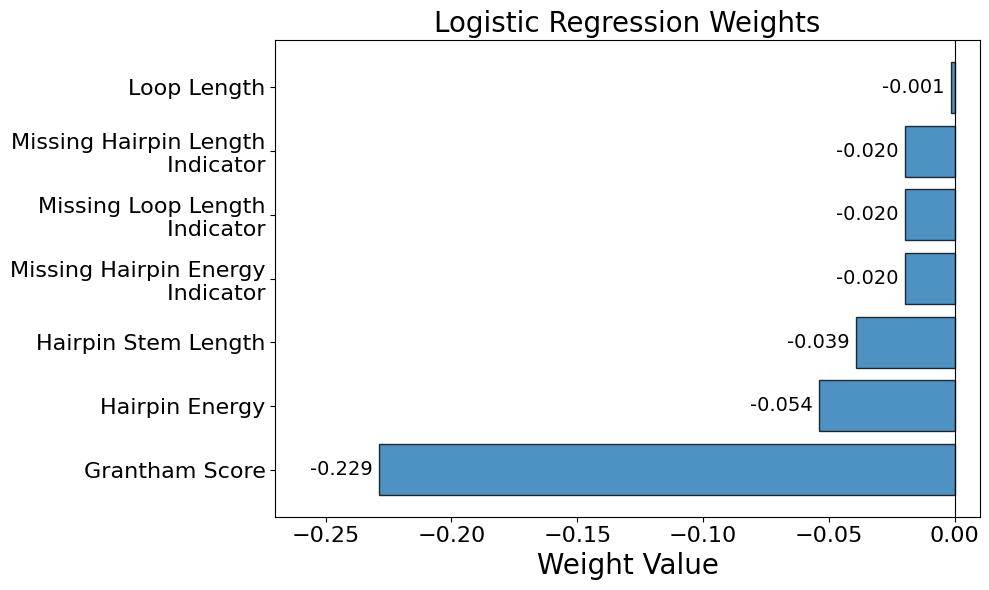

In [138]:
weight_features = log_reg_30_featured.coef_[0][-7:]
df_weights = pd.DataFrame({'feature': features_name, 'weight': weight_features})
df_weights = df_weights.sort_values(by='weight')

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df_weights['feature'], df_weights['weight'], edgecolor='black', alpha=0.8)
ax.bar_label(bars, fmt='%.3f', padding=5, fontsize=14)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlim(-0.27, 0.01)
ax.set_title('Logistic Regression Weights', fontsize=20)
ax.set_xlabel('Weight Value', fontsize=20)
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# Evaluation of Predictive Performance

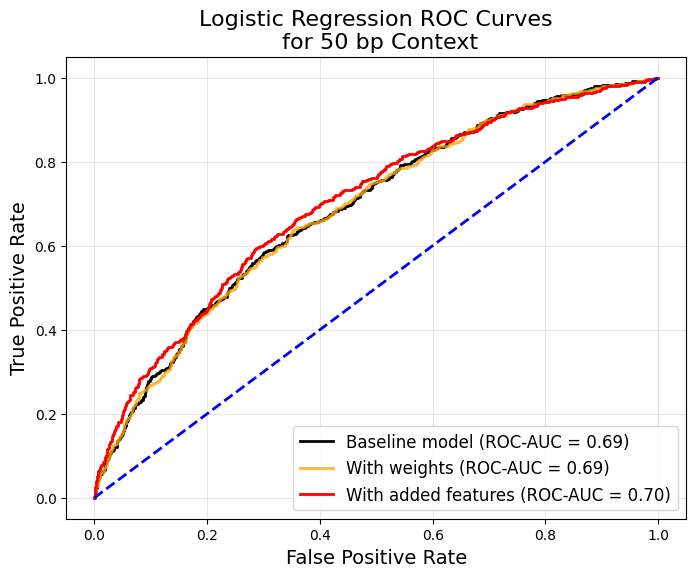

In [139]:
plt.figure(figsize=(8, 6))
models = [
    (fpr_50, tpr_50, 'Baseline model', 'black', '-', 1.0),
    (fpr_50_w, tpr_50_w, 'With weights', 'orange', '-', 0.8),
    (fpr_50_featured, tpr_50_featured, 'With added features', 'red', '-', 1.0),
]

for fpr, tpr, label, color, linestyle, alpha_val in models:
    current_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, linestyle=linestyle, alpha=alpha_val,
             label=f'{label} (ROC-AUC = {current_auc:.2f})')

plt.plot(np.linspace(0,1, 10), np.linspace(0,1, 10), '--', color='blue', lw=2)

plt.ylabel('True Positive Rate', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=14)
plt.title('Logistic Regression ROC Curves\n for 50 bp Context', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

plt.show()

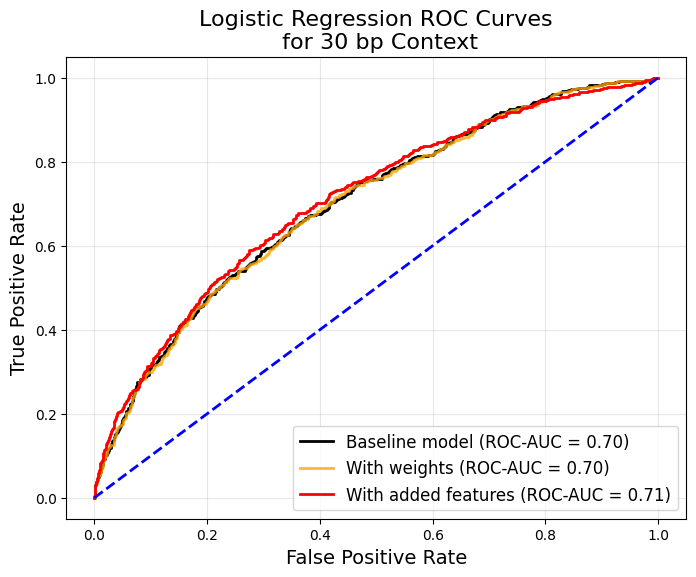

In [140]:
plt.figure(figsize=(8, 6))
models = [
    (fpr_30, tpr_30, 'Baseline model', 'black', '-', 1.0),
    (fpr_30_w, tpr_30_w, 'With weights', 'orange', '-', 0.8),
    (fpr_30_featured, tpr_30_featured, 'With added features', 'red', '-', 1.0),
]

for fpr, tpr, label, color, linestyle, alpha_val in models:
    current_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, linestyle=linestyle, alpha=alpha_val,
             label=f'{label} (ROC-AUC = {current_auc:.2f})')

plt.plot(np.linspace(0,1, 10), np.linspace(0,1, 10), '--', color='blue', lw=2)

plt.ylabel('True Positive Rate', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=14)
plt.title('Logistic Regression ROC Curves\n for 30 bp Context', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

plt.show()

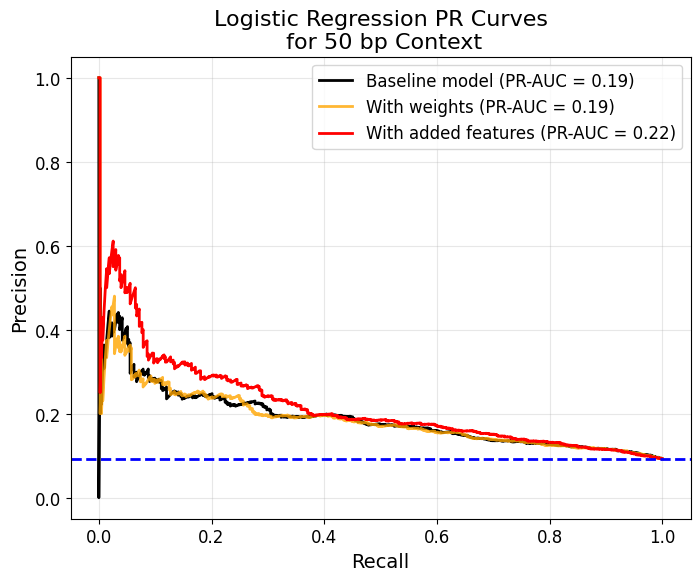

In [141]:
plt.figure(figsize=(8, 6))

pr_models = [
    (precision_50, recall_50, 'Baseline model', 'black', 1.0),
    (precision_50_w, recall_50_w, 'With weights', 'orange', 0.8),
    (precision_50_featured, recall_50_featured, 'With added features', 'red', 1.0),
]

random_level = Counter(y)[1] / (Counter(y)[0] + Counter(y)[1])

for prec, rec, label, color, alpha_val in pr_models:
    ap_score = auc(rec, prec)
    plt.plot(rec, prec, lw=2, color=color, alpha=alpha_val,
             label=f'{label} (PR-AUC = {ap_score:.2f})')

plt.axhline(y=random_level, color='blue', linestyle='--', lw=2)

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Logistic Regression PR Curves\n for 50 bp Context', fontsize=16)
plt.legend(loc="upper right", fontsize=12)
plt.grid(alpha=0.3)

plt.show()

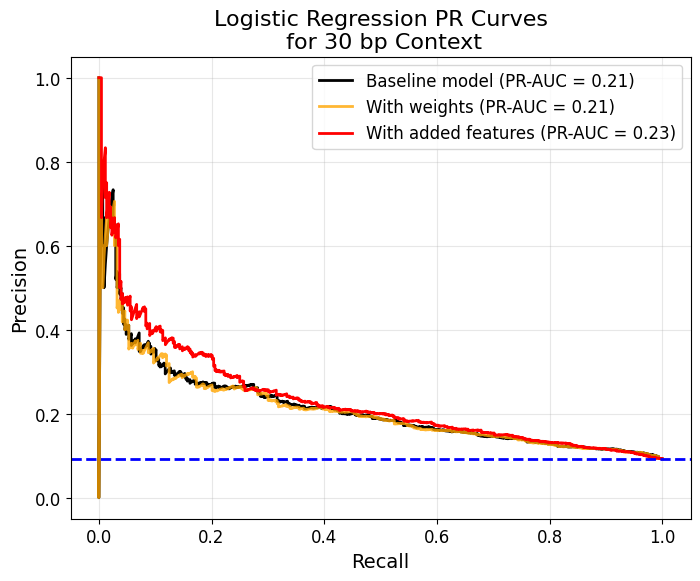

In [142]:
plt.figure(figsize=(8, 6))

pr_models = [
    (precision_30, recall_30, 'Baseline model', 'black', 1.0),
    (precision_30_w, recall_30_w, 'With weights', 'orange', 0.8),
    (precision_30_featured, recall_30_featured, 'With added features', 'red', 1.0),
]

random_level = Counter(y)[1] / (Counter(y)[0] + Counter(y)[1])

for prec, rec, label, color, alpha_val in pr_models:
    ap_score = auc(rec, prec)
    plt.plot(rec, prec, lw=2, color=color, alpha=alpha_val,
             label=f'{label} (PR-AUC = {ap_score:.2f})')

plt.axhline(y=random_level, color='blue', linestyle='--', lw=2)

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Logistic Regression PR Curves\n for 30 bp Context', fontsize=16)
plt.legend(loc="upper right", fontsize=12)
plt.grid(alpha=0.3)

plt.show()